# 06 — Arrival Regression (V9.0)

**RMSE Optuna + Quantile (Q05-Q95) + Sample Weighting + Prediction Intervals + SHAP + Lookahead**

In [1]:
# Standard imports
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

# ML imports
from catboost import CatBoostRegressor
import optuna
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score
)
import shap
import joblib
import json
import matplotlib.pyplot as plt

# Project imports
PROJECT_ROOT = Path('../../..')
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from features.lag_features import add_lag_features, add_congestion_features, compute_v4_lag_features
from features.aircraft_features import compute_prev_aircraft_delay

# Paths
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR = PROJECT_ROOT / 'models'
FIGURES_DIR = PROJECT_ROOT / 'outputs' / 'figures'
MODELS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print('Imports complete.')

Imports complete.


## 1. Load Data from NB03

In [2]:
# === Load prepared data from NB03 ===
import pickle

ctx = pickle.load(open(DATA_PROCESSED / 'arrival_model_context.pkl', 'rb'))
feature_columns = ctx['feature_columns']
X_train = ctx['X_train'].copy()
X_test = ctx['X_test'].copy()
y_train = ctx['y_train'].copy()
y_test = ctx['y_test'].copy()
train = ctx['train']
test = ctx['test']
cutoff = ctx['cutoff']

# Regression target: continuous delay minutes
y_train_reg = train['Total_Calculated_Delay'].copy() if 'Total_Calculated_Delay' in train.columns else train['Arr_Calculated_Delay'].copy()
y_test_reg = test['Total_Calculated_Delay'].copy() if 'Total_Calculated_Delay' in test.columns else test['Arr_Calculated_Delay'].copy()

print(f'Loaded from NB03: X_train={X_train.shape}, X_test={X_test.shape}')
print(f'Features ({len(feature_columns)}): {feature_columns}')
print(f'Regression target: train median={y_train_reg.median():.1f} min, test median={y_test_reg.median():.1f} min')

# Alias for regression code compatibility
X_train_reg = X_train.copy()
X_test_reg = X_test.copy()

train_medians = ctx.get('train_medians', X_train.median())


Loaded from NB03: X_train=(103204, 21), X_test=(43955, 21)
Features (21): ['delay_rate_1h', 'terminal_delay_1h', 'severe_delay_count_prev', 'delay_rolling_3h', 'lga_dep_delay_1h', 'prev_aircraft_delay', 'turnaround_hours', 'gate_delay_rate', 'faa_delay_reason', 'runway_delay_rate', 'airline_delay_rate', 'Hour', 'faa_delay_severity', 'runway_config_change', 'origin_dewpoint', 'origin_historical_delay', 'origin_wx_impact', 'route_risk_score', 'lga_wx_impact', 'faa_event_duration_hours', 'faa_active_event_count']
Regression target: train median=-5.0 min, test median=-6.0 min


## 2. Classification Sanity Check

In [3]:
# --- V9.0 Classification Sanity Check ---
# Quick validation: train CatBoost classifier with 19 features, compare to V7.0 Optuna AUC=0.8088
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score

y_train_cls = train['Is_Delayed'].copy()
y_test_cls = test['Is_Delayed'].copy()

_clf = CatBoostClassifier(
    iterations=300, depth=8, learning_rate=0.05,
    auto_class_weights='Balanced', random_seed=42, verbose=0
)
_clf.fit(X_train_reg, y_train_cls)
_auc = roc_auc_score(y_test_cls, _clf.predict_proba(X_test_reg)[:, 1])

print(f'--- V9.0 Classification Sanity Check ---')
print(f'CatBoost (19 features, simple): AUC={_auc:.4f}  (V7.0 Optuna ref: 0.8088)')
print(f'  {"PASS" if _auc >= 0.795 else "WARNING: AUC dropped significantly — investigate before proceeding"}')
del _clf

--- V9.0 Classification Sanity Check ---
CatBoost (19 features, simple): AUC=0.8071  (V7.0 Optuna ref: 0.8088)
  PASS


## 3. Target Distribution

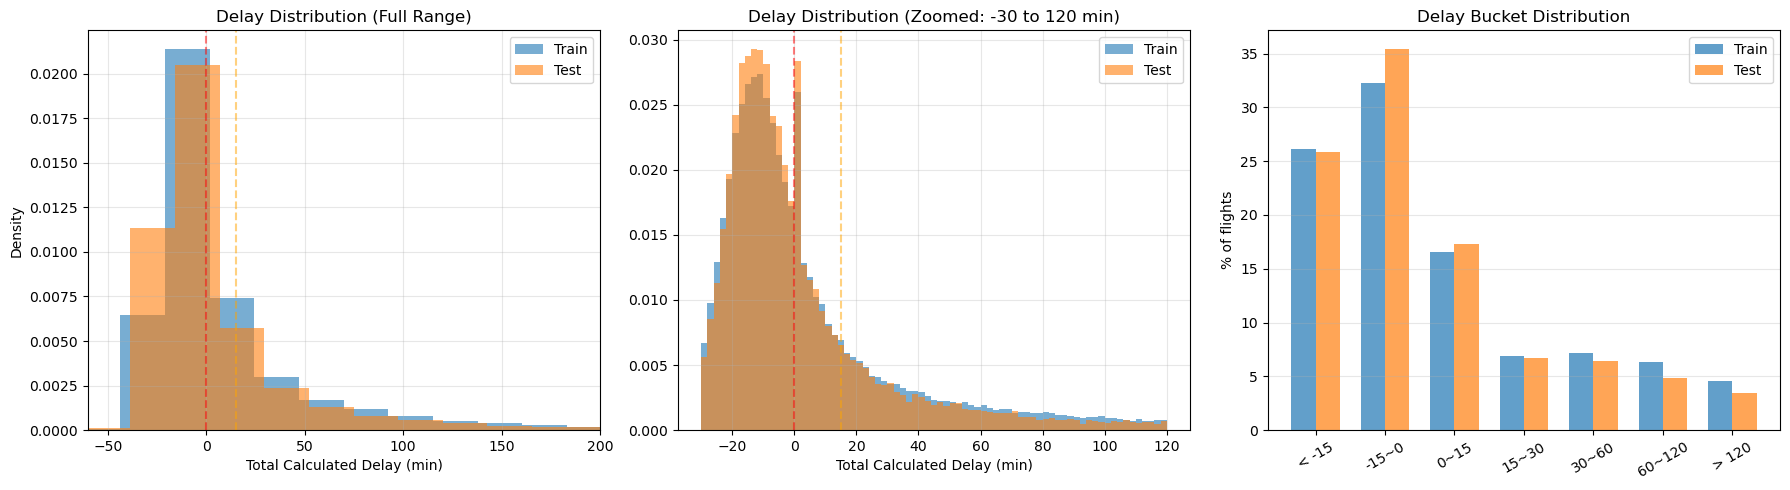


Delay Bucket Distribution:
Bucket            Train   Train%       Test    Test%
--------------------------------------------------
< -15            26,993    26.2%     11,382    25.9%
-15~0            33,313    32.3%     15,556    35.4%
0~15             17,105    16.6%      7,593    17.3%
15~30             7,095     6.9%      2,946     6.7%
30~60             7,427     7.2%      2,818     6.4%
60~120            6,516     6.3%      2,139     4.9%
> 120             4,755     4.6%      1,521     3.5%


In [4]:
# --- Distribution of Total_Calculated_Delay ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Full distribution
axes[0].hist(y_train_reg, bins=100, alpha=0.6, label='Train', density=True)
axes[0].hist(y_test_reg, bins=100, alpha=0.6, label='Test', density=True)
axes[0].set_xlabel('Total Calculated Delay (min)')
axes[0].set_ylabel('Density')
axes[0].set_title('Delay Distribution (Full Range)')
axes[0].legend()
axes[0].axvline(x=0, color='red', linestyle='--', alpha=0.5)
axes[0].axvline(x=15, color='orange', linestyle='--', alpha=0.5, label='DOT threshold')
axes[0].set_xlim(-60, 200)
axes[0].grid(True, alpha=0.3)

# Zoomed: -30 to 120 min
mask_train = (y_train_reg >= -30) & (y_train_reg <= 120)
mask_test = (y_test_reg >= -30) & (y_test_reg <= 120)
axes[1].hist(y_train_reg[mask_train], bins=75, alpha=0.6, label='Train', density=True)
axes[1].hist(y_test_reg[mask_test], bins=75, alpha=0.6, label='Test', density=True)
axes[1].set_xlabel('Total Calculated Delay (min)')
axes[1].set_title('Delay Distribution (Zoomed: -30 to 120 min)')
axes[1].axvline(x=0, color='red', linestyle='--', alpha=0.5)
axes[1].axvline(x=15, color='orange', linestyle='--', alpha=0.5)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Bucket analysis
buckets = [(-np.inf, -15), (-15, 0), (0, 15), (15, 30), (30, 60), (60, 120), (120, np.inf)]
bucket_labels = ['< -15', '-15~0', '0~15', '15~30', '30~60', '60~120', '> 120']
train_counts = [((y_train_reg >= lo) & (y_train_reg < hi)).sum() for lo, hi in buckets]
test_counts = [((y_test_reg >= lo) & (y_test_reg < hi)).sum() for lo, hi in buckets]

x_pos = np.arange(len(bucket_labels))
width = 0.35
axes[2].bar(x_pos - width/2, [c/len(y_train_reg)*100 for c in train_counts], width, label='Train', alpha=0.7)
axes[2].bar(x_pos + width/2, [c/len(y_test_reg)*100 for c in test_counts], width, label='Test', alpha=0.7)
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(bucket_labels, rotation=30)
axes[2].set_ylabel('% of flights')
axes[2].set_title('Delay Bucket Distribution')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'regression_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Print bucket table
print('\nDelay Bucket Distribution:')
print(f'{"Bucket":<12} {"Train":>10} {"Train%":>8} {"Test":>10} {"Test%":>8}')
print('-' * 50)
for label, tc, ec in zip(bucket_labels, train_counts, test_counts):
    print(f'{label:<12} {tc:>10,} {tc/len(y_train_reg)*100:>7.1f}% {ec:>10,} {ec/len(y_test_reg)*100:>7.1f}%')

## 4. RMSE Model (CatBoost Optuna)

In [5]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

def reg_objective(trial):
    """CatBoost Regressor Optuna: minimize RMSE."""
    params = {
        'iterations': trial.suggest_int('iterations', 200, 800),
        'depth': trial.suggest_int('depth', 6, 14),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 30.0),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 50),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'random_strength': trial.suggest_float('random_strength', 0.0, 3.0),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 5.0),
        'loss_function': 'RMSE',
        'random_seed': 42,
        'verbose': 0,
    }

    model = CatBoostRegressor(**params)
    model.fit(
        X_train_reg, y_train_reg,
        eval_set=(X_test_reg, y_test_reg),
        early_stopping_rounds=50,
        verbose=0,
    )
    preds = model.predict(X_test_reg)
    rmse = np.sqrt(mean_squared_error(y_test_reg, preds))
    mae = mean_absolute_error(y_test_reg, preds)
    r2 = r2_score(y_test_reg, preds)

    trial.set_user_attr('mae', mae)
    trial.set_user_attr('r2', r2)
    trial.set_user_attr('best_iteration', model.best_iteration_)
    return rmse  # minimize

study_reg = optuna.create_study(direction='minimize', study_name='catboost_regressor')
print('Starting CatBoost Regressor Optuna (100 trials, minimize RMSE)...')
study_reg.optimize(reg_objective, n_trials=100, show_progress_bar=True)

print(f'\nCatBoost Regressor Optuna complete!')
print(f'  Best trial: #{study_reg.best_trial.number}')
print(f'  Best RMSE:  {study_reg.best_value:.2f} min')
print(f'  Best MAE:   {study_reg.best_trial.user_attrs["mae"]:.2f} min')
print(f'  Best R²:    {study_reg.best_trial.user_attrs["r2"]:.4f}')
print(f'\nBest params:')
for k, v in study_reg.best_params.items():
    if isinstance(v, float):
        print(f'  {k}: {v:.6f}')
    else:
        print(f'  {k}: {v}')

Starting CatBoost Regressor Optuna (100 trials, minimize RMSE)...


  0%|          | 0/100 [00:00<?, ?it/s]


CatBoost Regressor Optuna complete!
  Best trial: #54
  Best RMSE:  49.95 min
  Best MAE:   22.54 min
  Best R²:    0.2754

Best params:
  iterations: 746
  depth: 8
  learning_rate: 0.073537
  l2_leaf_reg: 5.906529
  min_data_in_leaf: 40
  subsample: 0.849916
  colsample_bylevel: 0.784718
  random_strength: 2.772763
  bagging_temperature: 2.549614


### 4.1 Top 10 Trials

In [6]:
# --- Top 10 trials analysis ---
reg_trials_df = study_reg.trials_dataframe().sort_values('value', ascending=True)
print('CatBoost Regressor - Top 10 trials (lowest RMSE):')
print(f'{"Trial":<8} {"RMSE":>8} {"MAE":>8} {"R²":>8} {"depth":>8} {"lr":>10} {"iter":>8}')
print('-' * 65)
for _, row in reg_trials_df.head(10).iterrows():
    print(f'{int(row["number"]):<8} {row["value"]:>8.2f} '
          f'{row["user_attrs_mae"]:>8.2f} '
          f'{row["user_attrs_r2"]:>8.4f} '
          f'{int(row["params_depth"]):>8} '
          f'{row["params_learning_rate"]:>10.4f} '
          f'{int(row["params_iterations"]):>8}')

# Bound check
print('\nParameter bound check (top 10):')
top10 = reg_trials_df.head(10)
for param, low, high in [('params_depth', 6, 14), ('params_iterations', 200, 800)]:
    at_low = (top10[param] <= low + 0.1).sum()
    at_high = (top10[param] >= high - 0.1).sum()
    if at_low > 0 or at_high > 0:
        print(f'  {param}: {at_low} at lower bound, {at_high} at upper bound')
    else:
        print(f'  {param}: no bound issues')

CatBoost Regressor - Top 10 trials (lowest RMSE):
Trial        RMSE      MAE       R²    depth         lr     iter
-----------------------------------------------------------------
54          49.95    22.54   0.2754        8     0.0735      746
96          49.99    22.74   0.2741        8     0.0691      743
72          50.00    22.46   0.2740        7     0.0679      780
58          50.03    22.40   0.2731        9     0.0995      716
79          50.03    22.38   0.2730        7     0.0531      799
43          50.04    22.44   0.2727        7     0.0643      713
31          50.05    22.53   0.2726        7     0.0659      634
41          50.05    22.30   0.2724        7     0.0576      695
66          50.06    22.38   0.2722        9     0.0873      682
98          50.06    22.33   0.2720        9     0.0593      676

Parameter bound check (top 10):
  params_depth: no bound issues
  params_iterations: no bound issues


### 4.2 Train Final Model

In [7]:
# --- Train final regressor with best params ---
best_reg_params = study_reg.best_params.copy()
best_reg_params['loss_function'] = 'RMSE'
best_reg_params['random_seed'] = 42
best_reg_params['verbose'] = 0

reg_model = CatBoostRegressor(**best_reg_params)
reg_model.fit(
    X_train_reg, y_train_reg,
    eval_set=(X_test_reg, y_test_reg),
    early_stopping_rounds=50,
    verbose=0,
)

y_pred_reg = reg_model.predict(X_test_reg)

rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
mae = mean_absolute_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)

print(f'Final CatBoost Regressor:')
print(f'  RMSE: {rmse:.2f} min')
print(f'  MAE:  {mae:.2f} min')
print(f'  R²:   {r2:.4f}')
print(f'  Best iteration: {reg_model.best_iteration_}')

Final CatBoost Regressor:
  RMSE: 49.95 min
  MAE:  22.54 min
  R²:   0.2754
  Best iteration: 569


## 5. Quantile Models (Q05/Q10/Q50/Q90/Q95)

In [8]:
# --- 3.2 Quantile Regression Optuna (5 models: Q05, Q10, Q50, Q90, Q95) ---
optuna.logging.set_verbosity(optuna.logging.WARNING)

quantile_configs = {'q05': 0.05, 'q10': 0.1, 'q50': 0.5, 'q90': 0.9, 'q95': 0.95}
quantile_studies = {}
quantile_models = {}
quantile_preds = {}

for qname, alpha in quantile_configs.items():
    print(f'\n{"="*60}')
    print(f'Training {qname.upper()} model (alpha={alpha})')
    print('='*60)

    def make_objective(alpha_val):
        def objective(trial):
            params = {
                'iterations': trial.suggest_int('iterations', 200, 800),
                'depth': trial.suggest_int('depth', 6, 14),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
                'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 30.0),
                'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 50),
                'subsample': trial.suggest_float('subsample', 0.6, 1.0),
                'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
                'random_strength': trial.suggest_float('random_strength', 0.0, 3.0),
                'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 5.0),
                'loss_function': f'Quantile:alpha={alpha_val}',
                'random_seed': 42,
                'verbose': 0,
            }
            model = CatBoostRegressor(**params)
            model.fit(
                X_train_reg, y_train_reg,
                eval_set=(X_test_reg, y_test_reg),
                early_stopping_rounds=50,
                verbose=0,
            )
            preds = model.predict(X_test_reg)
            # Quantile (pinball) loss
            errors = y_test_reg.values - preds
            ql = np.mean(np.where(errors >= 0, alpha_val * errors, (alpha_val - 1) * errors))
            mae = mean_absolute_error(y_test_reg, preds)
            trial.set_user_attr('mae', mae)
            trial.set_user_attr('best_iteration', model.best_iteration_)
            return ql  # minimize
        return objective

    study = optuna.create_study(direction='minimize', study_name=f'catboost_{qname}')
    study.optimize(make_objective(alpha), n_trials=50, show_progress_bar=True)
    quantile_studies[qname] = study

    # Train final model with best params
    best_params = study.best_params.copy()
    best_params['loss_function'] = f'Quantile:alpha={alpha}'
    best_params['random_seed'] = 42
    best_params['verbose'] = 0

    model = CatBoostRegressor(**best_params)
    model.fit(
        X_train_reg, y_train_reg,
        eval_set=(X_test_reg, y_test_reg),
        early_stopping_rounds=50,
        verbose=0,
    )
    quantile_models[qname] = model
    quantile_preds[qname] = model.predict(X_test_reg)

    preds = quantile_preds[qname]
    q_mae = mean_absolute_error(y_test_reg, preds)
    print(f'\n{qname.upper()} Results:')
    print(f'  Best trial: #{study.best_trial.number}')
    print(f'  Quantile loss: {study.best_value:.4f}')
    print(f'  MAE: {q_mae:.2f} min')
    print(f'  Best params: depth={best_params["depth"]}, lr={best_params["learning_rate"]:.4f}, iter={best_params["iterations"]}')

print('\n' + '='*60)
print('All quantile models trained.')
print(f'  RMSE model MAE: {mae:.2f} min')
for qn, qp in quantile_preds.items():
    print(f'  {qn.upper()} MAE: {mean_absolute_error(y_test_reg, qp):.2f} min')

# Convenient aliases
pred_q05 = quantile_preds['q05']
pred_q10 = quantile_preds['q10']
pred_q50 = quantile_preds['q50']
pred_q90 = quantile_preds['q90']
pred_q95 = quantile_preds['q95']


Training Q05 model (alpha=0.05)


  0%|          | 0/50 [00:00<?, ?it/s]


Q05 Results:
  Best trial: #45
  Quantile loss: 1.7902
  MAE: 31.62 min
  Best params: depth=7, lr=0.0624, iter=549

Training Q10 model (alpha=0.1)


  0%|          | 0/50 [00:00<?, ?it/s]


Q10 Results:
  Best trial: #41
  Quantile loss: 3.2212
  MAE: 27.99 min
  Best params: depth=8, lr=0.0278, iter=571

Training Q50 model (alpha=0.5)


...


Q50 Results:
  Best trial: #32
  Quantile loss: 10.0588
  MAE: 20.12 min
  Best params: depth=8, lr=0.0712, iter=800

Training Q90 model (alpha=0.9)


  0%|          | 0/50 [00:00<?, ?it/s]


Q90 Results:
  Best trial: #31
  Quantile loss: 8.5258
  MAE: 41.13 min
  Best params: depth=8, lr=0.0405, iter=669

Training Q95 model (alpha=0.95)


  0%|          | 0/50 [00:00<?, ?it/s]


Q95 Results:
  Best trial: #9
  Quantile loss: 6.5408
  MAE: 65.44 min
  Best params: depth=8, lr=0.0102, iter=797

All quantile models trained.
  RMSE model MAE: 22.54 min
  Q05 MAE: 31.62 min
  Q10 MAE: 27.99 min
  Q50 MAE: 20.12 min
  Q90 MAE: 41.13 min
  Q95 MAE: 65.44 min


## 6. Sample Weighting Test

In [9]:
# --- 3.3 Sample Weighting Experiment ---
# Upweight flights with large delays: weight = 1 + clip(delay/60, 0, 5)
# A 120-min delay gets weight=3.0, a 300-min delay gets weight=6.0 (capped)
# Compare bucket-level bias with/without weighting

weights = np.ones(len(y_train_reg))
delayed_mask = y_train_reg > 15
weights[delayed_mask] = 1 + np.clip(y_train_reg[delayed_mask] / 60, 0, 5)
print(f'Sample weights: min={weights.min():.1f}, max={weights.max():.1f}, mean={weights.mean():.2f}')
print(f'  Flights with weight > 1: {(weights > 1).sum():,} ({(weights > 1).mean()*100:.1f}%)')

# Train weighted RMSE model with same best params
weighted_params = best_reg_params.copy()
weighted_model = CatBoostRegressor(**weighted_params)
weighted_model.fit(
    X_train_reg, y_train_reg,
    sample_weight=weights,
    eval_set=(X_test_reg, y_test_reg),
    early_stopping_rounds=50,
    verbose=0,
)
y_pred_weighted = weighted_model.predict(X_test_reg)

# Compare bucket-level bias
buckets = [(-np.inf, -15), (-15, 0), (0, 15), (15, 30), (30, 60), (60, 120), (120, np.inf)]
bucket_labels = ['< -15', '-15~0', '0~15', '15~30', '30~60', '60~120', '> 120']

print('\n' + '=' * 90)
print('SAMPLE WEIGHTING ABLATION: Unweighted vs Weighted RMSE')
print('=' * 90)
print(f'{"Bucket":<10} {"N":>6} {"Actual":>8} {"Unwt Pred":>10} {"Wt Pred":>10} {"Unwt Bias":>10} {"Wt Bias":>10} {"Δ Bias":>8}')
print('-' * 75)

tail_improved = False
for label, (lo, hi) in zip(bucket_labels, buckets):
    mask = (y_test_reg >= lo) & (y_test_reg < hi)
    n = mask.sum()
    if n > 0:
        act = y_test_reg[mask].mean()
        unwt = y_pred_reg[mask].mean()
        wt = y_pred_weighted[mask].mean()
        unwt_bias = unwt - act
        wt_bias = wt - act
        delta = abs(wt_bias) - abs(unwt_bias)
        print(f'{label:<10} {n:>6} {act:>8.1f} {unwt:>10.1f} {wt:>10.1f} {unwt_bias:>+10.1f} {wt_bias:>+10.1f} {delta:>+8.1f}')
        if label in ['60~120', '> 120'] and abs(wt_bias) < abs(unwt_bias) - 10:
            tail_improved = True

mae_unwt = mean_absolute_error(y_test_reg, y_pred_reg)
mae_wt = mean_absolute_error(y_test_reg, y_pred_weighted)
mae_degradation = mae_wt - mae_unwt
print(f'\nOverall MAE: Unweighted={mae_unwt:.2f}, Weighted={mae_wt:.2f}, Δ={mae_degradation:+.2f} min')

# Decision: tail must improve AND overall MAE degradation must be < 2 min
weighted_helps = tail_improved and mae_degradation < 2.0

if weighted_helps:
    print(f'\n→ DECISION: Tail improved AND MAE degradation acceptable ({mae_degradation:+.2f} < 2.0). KEEP.')
    use_weighted = True
else:
    if tail_improved:
        print(f'\n→ DECISION: Tail improved but MAE degradation too large ({mae_degradation:+.2f} >> 2.0). REJECT.')
    else:
        print(f'\n→ DECISION: Tail did not improve sufficiently. REJECT.')
    use_weighted = False

Sample weights: min=1.0, max=6.0, mean=1.31
  Flights with weight > 1: 25,151 (24.4%)

SAMPLE WEIGHTING ABLATION: Unweighted vs Weighted RMSE
Bucket          N   Actual  Unwt Pred    Wt Pred  Unwt Bias    Wt Bias   Δ Bias
---------------------------------------------------------------------------
< -15       11382    -22.0       -1.8       14.4      +20.3      +36.4    +16.2
-15~0       15556     -8.7        0.8       16.7       +9.5      +25.4    +15.8
0~15         7593      5.0        7.0       24.2       +1.9      +19.2    +17.3
15~30        2946     21.1       16.1       36.5       -5.0      +15.4    +10.4
30~60        2818     42.6       27.5       49.9      -15.1       +7.3     -7.8
60~120       2139     84.0       45.3       70.6      -38.7      -13.4    -25.2
> 120        1521    231.8       88.6      115.1     -143.2     -116.7    -26.6

Overall MAE: Unweighted=22.54, Weighted=33.42, Δ=+10.88 min

→ DECISION: Tail improved but MAE degradation too large (+10.88 >> 2.0). REJECT.

## 7. Point Estimate Evaluation

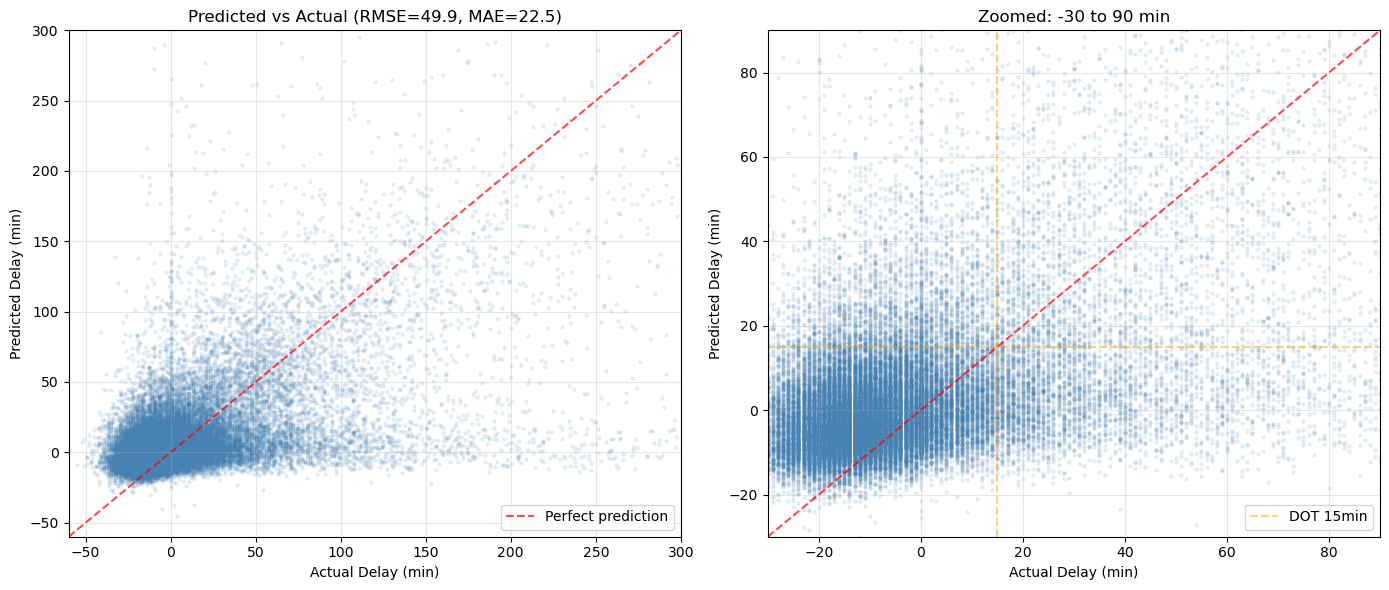

Saved: regression_scatter.png


In [10]:
# --- 4.1 Predicted vs Actual scatter ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Full range scatter
axes[0].scatter(y_test_reg, y_pred_reg, alpha=0.1, s=5, c='steelblue')
lims = [min(y_test_reg.min(), y_pred_reg.min()), max(y_test_reg.max(), y_pred_reg.max())]
lims = [max(lims[0], -60), min(lims[1], 300)]
axes[0].plot(lims, lims, 'r--', alpha=0.7, label='Perfect prediction')
axes[0].set_xlabel('Actual Delay (min)')
axes[0].set_ylabel('Predicted Delay (min)')
axes[0].set_title(f'Predicted vs Actual (RMSE={rmse:.1f}, MAE={mae:.1f})')
axes[0].set_xlim(lims)
axes[0].set_ylim(lims)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Zoomed: -30 to 90 min
mask = (y_test_reg >= -30) & (y_test_reg <= 90)
axes[1].scatter(y_test_reg[mask], y_pred_reg[mask], alpha=0.1, s=5, c='steelblue')
axes[1].plot([-30, 90], [-30, 90], 'r--', alpha=0.7)
axes[1].axvline(x=15, color='orange', linestyle='--', alpha=0.5, label='DOT 15min')
axes[1].axhline(y=15, color='orange', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Actual Delay (min)')
axes[1].set_ylabel('Predicted Delay (min)')
axes[1].set_title('Zoomed: -30 to 90 min')
axes[1].set_xlim(-30, 90)
axes[1].set_ylim(-30, 90)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'regression_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: regression_scatter.png')

### 7.1 Bucket Analysis

In [11]:
# --- 4.2 Bucket-Level Bias: RMSE vs Q50 vs Q90 ---
buckets = [(-np.inf, -15), (-15, 0), (0, 15), (15, 30), (30, 60), (60, 120), (120, np.inf)]
bucket_labels = ['< -15', '-15~0', '0~15', '15~30', '30~60', '60~120', '> 120']

print('=' * 100)
print('BUCKET ANALYSIS: RMSE vs Q50 vs Q90')
print('=' * 100)
print(f'{"Bucket":<10} {"N":>6} {"Actual":>8} {"RMSE":>8} {"Q50":>8} {"Q90":>8} {"RMSE Bias":>10} {"Q50 Bias":>10} {"Q90 Bias":>10}')
print('-' * 100)

for label, (lo, hi) in zip(bucket_labels, buckets):
    mask = (y_test_reg >= lo) & (y_test_reg < hi)
    n = mask.sum()
    if n > 0:
        act = y_test_reg[mask].mean()
        rmse_pred = y_pred_reg[mask].mean()
        q50_pred = quantile_preds['q50'][mask].mean()
        q90_pred = quantile_preds['q90'][mask].mean()
        print(f'{label:<10} {n:>6} {act:>8.1f} {rmse_pred:>8.1f} {q50_pred:>8.1f} {q90_pred:>8.1f} '
              f'{rmse_pred - act:>+10.1f} {q50_pred - act:>+10.1f} {q90_pred - act:>+10.1f}')

BUCKET ANALYSIS: RMSE vs Q50 vs Q90
Bucket          N   Actual     RMSE      Q50      Q90  RMSE Bias   Q50 Bias   Q90 Bias
----------------------------------------------------------------------------------------------------
< -15       11382    -22.0     -1.8     -9.9     22.1      +20.3      +12.1      +44.1
-15~0       15556     -8.7      0.8     -7.1     25.8       +9.5       +1.6      +34.5
0~15         7593      5.0      7.0     -1.9     34.7       +1.9       -6.9      +29.7
15~30        2946     21.1     16.1      5.4     52.1       -5.0      -15.8      +30.9
30~60        2818     42.6     27.5     15.3     68.4      -15.1      -27.3      +25.8
60~120       2139     84.0     45.3     31.2     93.8      -38.7      -52.8       +9.8
> 120        1521    231.8     88.6     63.9    148.3     -143.2     -167.9      -83.4


### 7.2 Calibration by Decile

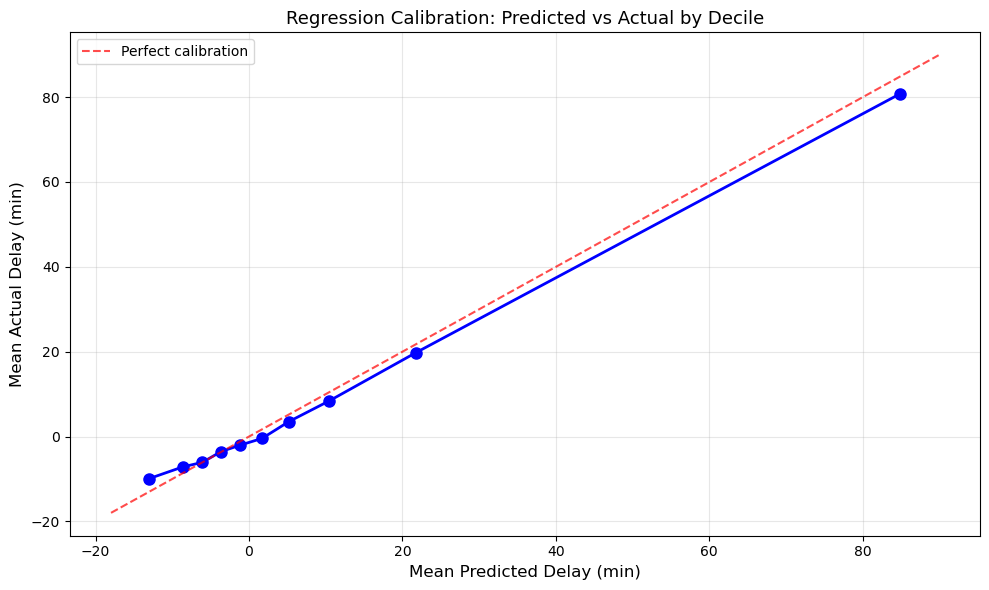


Calibration by decile:
      Decile  Pred Mean   Act Mean     Bias       N
--------------------------------------------------
(-44.976, -10.151]      -13.0       -9.9     -3.1    4396
(-10.151, -7.29]       -8.6       -7.2     -1.5    4395
(-7.29, -4.861]       -6.1       -6.1     +0.0    4396
(-4.861, -2.436]       -3.7       -3.6     -0.1    4395
(-2.436, 0.206]       -1.1       -2.0     +0.9    4396
(0.206, 3.31]        1.7       -0.4     +2.1    4395
(3.31, 7.346]        5.2        3.5     +1.7    4395
(7.346, 14.329]       10.5        8.4     +2.1    4396
(14.329, 34.011]       21.8       19.8     +2.0    4395
(34.011, 623.169]       84.9       80.8     +4.1    4396


In [12]:
# --- 4.3 Calibration: predicted vs actual by decile ---
fig, ax = plt.subplots(figsize=(10, 6))

# Bin predictions into deciles
pred_deciles = pd.qcut(y_pred_reg, q=10, duplicates='drop')
cal_df = pd.DataFrame({
    'actual': y_test_reg.values,
    'predicted': y_pred_reg,
    'decile': pred_deciles,
})

cal_summary = cal_df.groupby('decile', observed=True).agg(
    pred_mean=('predicted', 'mean'),
    actual_mean=('actual', 'mean'),
    count=('actual', 'count'),
).reset_index()

ax.plot(cal_summary['pred_mean'], cal_summary['actual_mean'], 'bo-', markersize=8, linewidth=2)
lims = [cal_summary[['pred_mean', 'actual_mean']].min().min() - 5,
        cal_summary[['pred_mean', 'actual_mean']].max().max() + 5]
ax.plot(lims, lims, 'r--', alpha=0.7, label='Perfect calibration')
ax.set_xlabel('Mean Predicted Delay (min)', fontsize=12)
ax.set_ylabel('Mean Actual Delay (min)', fontsize=12)
ax.set_title('Regression Calibration: Predicted vs Actual by Decile', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'regression_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCalibration by decile:')
print(f'{"Decile":>12} {"Pred Mean":>10} {"Act Mean":>10} {"Bias":>8} {"N":>7}')
print('-' * 50)
for _, row in cal_summary.iterrows():
    print(f'{str(row["decile"]):>12} {row["pred_mean"]:>10.1f} {row["actual_mean"]:>10.1f} '
          f'{row["pred_mean"] - row["actual_mean"]:>+8.1f} {int(row["count"]):>7}')

### 7.3 Post-hoc Calibration

In [13]:
# --- 4.3b Post-hoc Regression Calibration (Isotonic) ---
# Analogous to classification's isotonic calibration:
# Fit monotonic mapping from predicted → actual to correct systematic bias.
# Use 5-fold CV on training set to generate out-of-fold predictions (avoid overfitting).

from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import KFold

# Generate OOF predictions for calibrator fitting
kf = KFold(n_splits=5, shuffle=False)  # no shuffle for time series
oof_preds_q50 = np.zeros(len(X_train_reg))
oof_preds_q90 = np.zeros(len(X_train_reg))

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train_reg)):
    X_tr, X_val = X_train_reg.iloc[tr_idx], X_train_reg.iloc[val_idx]
    y_tr = y_train_reg.iloc[tr_idx]

    # Q50 fold model
    _q50 = CatBoostRegressor(
        **{k: v for k, v in quantile_studies['q50'].best_params.items()},
        loss_function='Quantile:alpha=0.5', random_seed=42, verbose=0
    )
    _q50.fit(X_tr, y_tr, verbose=0)
    oof_preds_q50[val_idx] = _q50.predict(X_val)

    # Q90 fold model
    _q90 = CatBoostRegressor(
        **{k: v for k, v in quantile_studies['q90'].best_params.items()},
        loss_function='Quantile:alpha=0.9', random_seed=42, verbose=0
    )
    _q90.fit(X_tr, y_tr, verbose=0)
    oof_preds_q90[val_idx] = _q90.predict(X_val)

# Fit isotonic calibrators
cal_q50 = IsotonicRegression(out_of_bounds='clip')
cal_q50.fit(oof_preds_q50, y_train_reg.values)

cal_q90 = IsotonicRegression(out_of_bounds='clip')
cal_q90.fit(oof_preds_q90, y_train_reg.values)

# Apply to test predictions
pred_q50_cal = cal_q50.predict(pred_q50)
pred_q90_cal = cal_q90.predict(pred_q90)

# Compare calibrated vs uncalibrated
print('=' * 80)
print('POST-HOC REGRESSION CALIBRATION (Isotonic)')
print('=' * 80)

mae_q50_uncal = mean_absolute_error(y_test_reg, pred_q50)
mae_q50_cal = mean_absolute_error(y_test_reg, pred_q50_cal)
mae_q90_uncal = mean_absolute_error(y_test_reg, pred_q90)
mae_q90_cal = mean_absolute_error(y_test_reg, pred_q90_cal)

print(f'\nQ50: MAE uncalibrated={mae_q50_uncal:.2f}, calibrated={mae_q50_cal:.2f}, Δ={mae_q50_cal - mae_q50_uncal:+.2f}')
print(f'Q90: MAE uncalibrated={mae_q90_uncal:.2f}, calibrated={mae_q90_cal:.2f}, Δ={mae_q90_cal - mae_q90_uncal:+.2f}')

# Bucket-level comparison for Q50
print(f'\nQ50 Calibration by Bucket:')
print(f'{"Bucket":<10} {"N":>6} {"Actual":>8} {"Q50":>8} {"Q50 Cal":>8} {"Bias":>8} {"Cal Bias":>8}')
print('-' * 60)
for label, (lo, hi) in zip(bucket_labels, buckets):
    mask = (y_test_reg >= lo) & (y_test_reg < hi)
    n = mask.sum()
    if n > 0:
        act = y_test_reg[mask].mean()
        q50_mean = pred_q50[mask].mean()
        q50_cal_mean = pred_q50_cal[mask].mean()
        print(f'{label:<10} {n:>6} {act:>8.1f} {q50_mean:>8.1f} {q50_cal_mean:>8.1f} '
              f'{q50_mean - act:>+8.1f} {q50_cal_mean - act:>+8.1f}')

# Verdict
q50_cal_helps = mae_q50_cal < mae_q50_uncal
print(f'\n--- Calibration Verdict ---')
print(f'Q50: {"IMPROVED" if q50_cal_helps else "WORSE"} (Δ MAE = {mae_q50_cal - mae_q50_uncal:+.2f}) '
      f'→ {"Deploy calibrated" if q50_cal_helps else "Use UNCALIBRATED (lower MAE)"}')
print(f'Q90: MAE {"improved" if mae_q90_cal < mae_q90_uncal else "worse"} but Q90 purpose is upper bound, not MAE minimization')
print(f'     → Use UNCALIBRATED Q90 to preserve upper-bound semantics')
print(f'\nProduction: Q50 uncalibrated (MAE={mae_q50_uncal:.2f}), Q90 uncalibrated (upper bound)')
print(f'Calibrators saved for reference but NOT deployed.')

POST-HOC REGRESSION CALIBRATION (Isotonic)

Q50: MAE uncalibrated=20.12, calibrated=22.20, Δ=+2.08
Q90: MAE uncalibrated=41.13, calibrated=22.68, Δ=-18.45

Q50 Calibration by Bucket:
Bucket          N   Actual      Q50  Q50 Cal     Bias Cal Bias
------------------------------------------------------------
< -15       11382    -22.0     -9.9     -1.4    +12.1    +20.6
-15~0       15556     -8.7     -7.1      1.7     +1.6    +10.5
0~15         7593      5.0     -1.9      7.4     -6.9     +2.4
15~30        2946     21.1      5.4     14.3    -15.8     -6.8
30~60        2818     42.6     15.3     23.6    -27.3    -19.0
60~120       2139     84.0     31.2     39.5    -52.8    -44.5
> 120        1521    231.8     63.9     74.3   -167.9   -157.5

--- Calibration Verdict ---
Q50: WORSE (Δ MAE = +2.08) → Use UNCALIBRATED (lower MAE)
Q90: MAE improved but Q90 purpose is upper bound, not MAE minimization
     → Use UNCALIBRATED Q90 to preserve upper-bound semantics

Production: Q50 uncalibrated (M

### 7.4 Derived Binary Classification

In [14]:
# --- 4.4 Derived Binary Classification ---
# Compare regression models' ability to classify delays (threshold: predicted > 15 min)
# This shows whether regression can substitute for the dedicated classifier.

print('--- Derived Binary Classification (predicted > 15 min = delayed) ---')
print(f'{"Model":<20} {"Precision":>10} {"Recall":>10} {"F1":>10} {"MAE":>8}')
print('-' * 65)

from sklearn.metrics import precision_score, recall_score, f1_score

for name, preds in [('RMSE', y_pred_reg), ('Q50', pred_q50), ('Q90', pred_q90)]:
    y_binary = (preds > 15).astype(int)
    prec = precision_score(y_test_cls, y_binary, zero_division=0)
    rec = recall_score(y_test_cls, y_binary, zero_division=0)
    f1 = f1_score(y_test_cls, y_binary, zero_division=0)
    model_mae = mean_absolute_error(y_test_reg, preds)
    print(f'{name:<20} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f} {model_mae:>8.2f}')

print('\n--- Summary ---')
print(f'Q50 vs RMSE: Q50 is the median-based estimator (less sensitive to outliers)')
print(f'Q90: captures 90th percentile — useful for worst-case planning')
print(f'Dashboard: show Q50 as "Expected delay", [Q10, Q90] as "Confidence range"')

--- Derived Binary Classification (predicted > 15 min = delayed) ---
Model                 Precision     Recall         F1      MAE
-----------------------------------------------------------------
RMSE                     0.5766     0.5336     0.5543    22.54
Q50                      0.7617     0.3887     0.5147    20.12
Q90                      0.2835     0.8993     0.4311    41.13

--- Summary ---
Q50 vs RMSE: Q50 is the median-based estimator (less sensitive to outliers)
Q90: captures 90th percentile — useful for worst-case planning
Dashboard: show Q50 as "Expected delay", [Q10, Q90] as "Confidence range"


## 8. Prediction Intervals

In [15]:
# --- 5.1 Prediction Interval Coverage ---

# 80% interval: [Q10, Q90]
coverage_80 = np.mean((y_test_reg.values >= pred_q10) & (y_test_reg.values <= pred_q90))
# 90% interval: [Q05, Q95]
coverage_90 = np.mean((y_test_reg.values >= pred_q05) & (y_test_reg.values <= pred_q95))

# Q90/Q95 capture rates for delayed flights
delayed_mask = y_test_reg.values > 15
q90_capture_delayed = np.mean(y_test_reg.values[delayed_mask] <= pred_q90[delayed_mask])
q95_capture_delayed = np.mean(y_test_reg.values[delayed_mask] <= pred_q95[delayed_mask])

# Capture rates for severe delays (>60 min)
severe_mask = y_test_reg.values > 60
q90_capture_severe = np.mean(y_test_reg.values[severe_mask] <= pred_q90[severe_mask])
q95_capture_severe = np.mean(y_test_reg.values[severe_mask] <= pred_q95[severe_mask])

# Capture rates for extreme delays (>120 min)
extreme_mask = y_test_reg.values > 120
q90_capture_extreme = np.mean(y_test_reg.values[extreme_mask] <= pred_q90[extreme_mask])
q95_capture_extreme = np.mean(y_test_reg.values[extreme_mask] <= pred_q95[extreme_mask])

# Interval width statistics
interval_width_80 = pred_q90 - pred_q10
interval_width_90 = pred_q95 - pred_q05

print('=' * 70)
print('PREDICTION INTERVAL ANALYSIS')
print('=' * 70)

print(f'\n80% Prediction Interval [Q10, Q90]:')
print(f'  Overall coverage:  {coverage_80:.1%} (target: 80%)')
print(f'  Q90 capture (>15 min delayed): {q90_capture_delayed:.1%}')
print(f'  Q90 capture (>60 min severe):  {q90_capture_severe:.1%}')
print(f'  Q90 capture (>120 min extreme):{q90_capture_extreme:.1%}')
print(f'  Mean width:  {interval_width_80.mean():.1f} min')

print(f'\n90% Prediction Interval [Q05, Q95]:')
print(f'  Overall coverage:  {coverage_90:.1%} (target: 90%)')
print(f'  Q95 capture (>15 min delayed): {q95_capture_delayed:.1%}')
print(f'  Q95 capture (>60 min severe):  {q95_capture_severe:.1%}')
print(f'  Q95 capture (>120 min extreme):{q95_capture_extreme:.1%}')
print(f'  Mean width:  {interval_width_90.mean():.1f} min')

# Use 80% interval as primary for downstream references
interval_width = interval_width_80

# Coverage by bucket (both intervals)
print(f'\nCoverage by Delay Bucket:')
print(f'{"Bucket":<10} {"N":>6} {"80% Cov":>8} {"90% Cov":>8} {"80% Width":>10} {"90% Width":>10}')
print('-' * 55)
for label, (lo, hi) in zip(bucket_labels, buckets):
    mask = (y_test_reg >= lo) & (y_test_reg < hi)
    n = mask.sum()
    if n > 0:
        cov80 = np.mean((y_test_reg.values[mask] >= pred_q10[mask]) & (y_test_reg.values[mask] <= pred_q90[mask]))
        cov90 = np.mean((y_test_reg.values[mask] >= pred_q05[mask]) & (y_test_reg.values[mask] <= pred_q95[mask]))
        w80 = interval_width_80[mask].mean()
        w90 = interval_width_90[mask].mean()
        print(f'{label:<10} {n:>6} {cov80:>7.1%} {cov90:>7.1%} {w80:>10.1f} {w90:>10.1f}')

PREDICTION INTERVAL ANALYSIS

80% Prediction Interval [Q10, Q90]:
  Overall coverage:  80.0% (target: 80%)
  Q90 capture (>15 min delayed): 58.7%
  Q90 capture (>60 min severe):  42.2%
  Q90 capture (>120 min extreme):33.4%
  Mean width:  57.0 min

90% Prediction Interval [Q05, Q95]:
  Overall coverage:  90.2% (target: 90%)
  Q95 capture (>15 min delayed): 78.7%
  Q95 capture (>60 min severe):  59.8%
  Q95 capture (>120 min extreme):47.0%
  Mean width:  89.3 min

Coverage by Delay Bucket:
Bucket          N  80% Cov  90% Cov  80% Width  90% Width
-------------------------------------------------------
< -15       11382   67.4%   83.1%       45.9       74.2
-15~0       15556   98.1%   99.3%       47.6       76.5
0~15         7593   88.8%   95.7%       52.5       82.8
15~30        2946   75.7%   96.1%       68.3      104.6
30~60        2818   61.5%   86.4%       79.6      119.1
60~120       2139   48.2%   69.1%       97.1      142.9
> 120        1521   33.8%   47.4%      139.1      206.6


### 8.1 Quantile Visualization

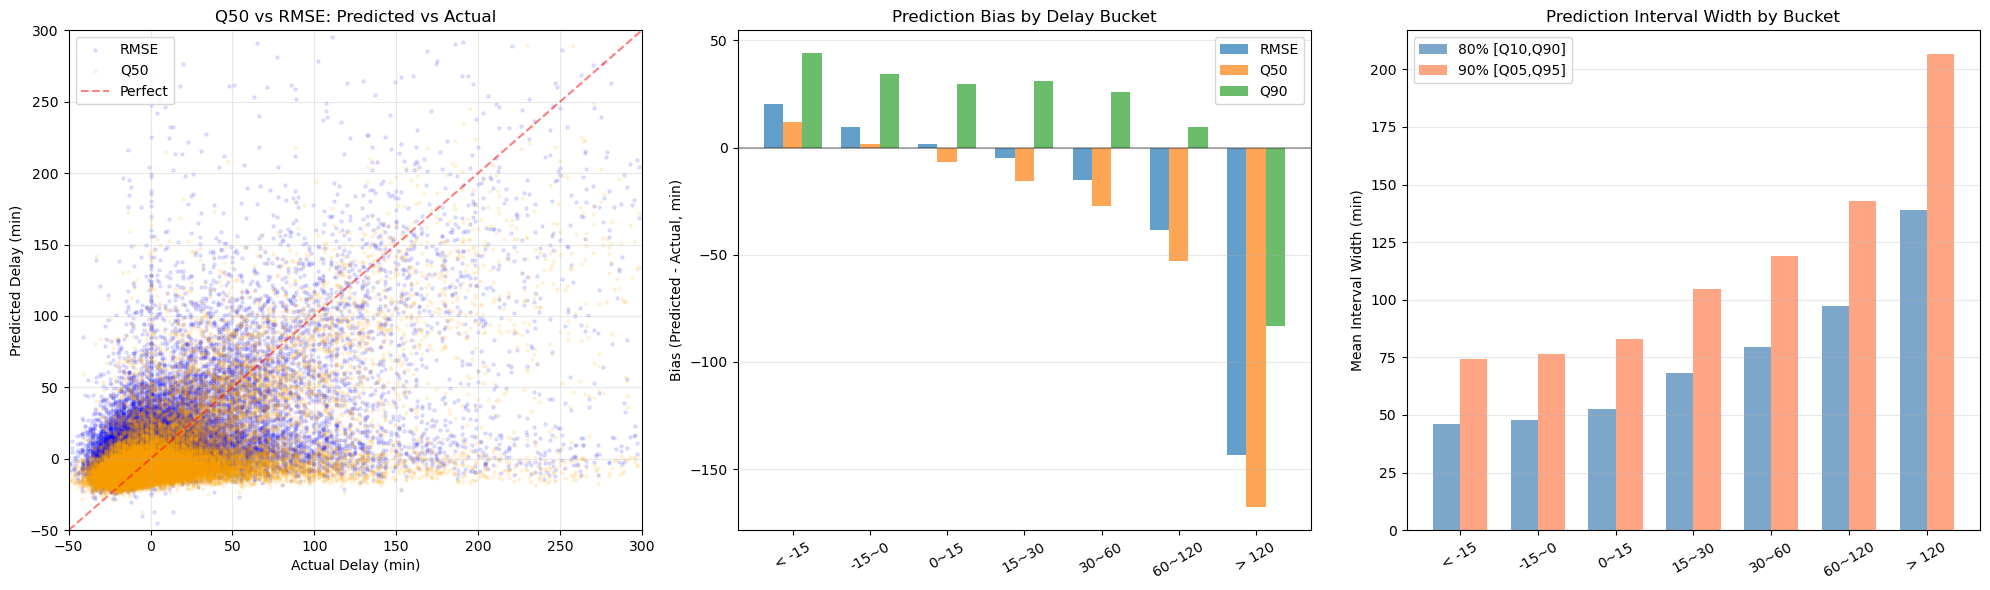

Saved: quantile_regression_analysis.png


In [16]:
# --- 5.2 Quantile Regression Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Predicted vs Actual: Q50 vs RMSE
ax = axes[0]
ax.scatter(y_test_reg, y_pred_reg, alpha=0.1, s=5, label='RMSE', color='blue')
ax.scatter(y_test_reg, pred_q50, alpha=0.1, s=5, label='Q50', color='orange')
ax.plot([-50, 300], [-50, 300], 'r--', alpha=0.5, label='Perfect')
ax.set_xlabel('Actual Delay (min)')
ax.set_ylabel('Predicted Delay (min)')
ax.set_title('Q50 vs RMSE: Predicted vs Actual')
ax.set_xlim(-50, 300)
ax.set_ylim(-50, 300)
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Bucket bias comparison
ax = axes[1]
rmse_biases = []
q50_biases = []
q90_biases = []
for (lo, hi) in buckets:
    mask = (y_test_reg >= lo) & (y_test_reg < hi)
    if mask.sum() > 0:
        act = y_test_reg[mask].mean()
        rmse_biases.append(y_pred_reg[mask].mean() - act)
        q50_biases.append(pred_q50[mask].mean() - act)
        q90_biases.append(pred_q90[mask].mean() - act)
x_pos = np.arange(len(bucket_labels))
width = 0.25
ax.bar(x_pos - width, rmse_biases, width, label='RMSE', alpha=0.7)
ax.bar(x_pos, q50_biases, width, label='Q50', alpha=0.7)
ax.bar(x_pos + width, q90_biases, width, label='Q90', alpha=0.7)
ax.set_xticks(x_pos)
ax.set_xticklabels(bucket_labels, rotation=30)
ax.set_ylabel('Bias (Predicted - Actual, min)')
ax.set_title('Prediction Bias by Delay Bucket')
ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 3. Prediction interval width by bucket (80% and 90%)
ax = axes[2]
w80_by_bucket = []
w90_by_bucket = []
for (lo, hi) in buckets:
    mask = (y_test_reg >= lo) & (y_test_reg < hi)
    if mask.sum() > 0:
        w80_by_bucket.append((pred_q90[mask] - pred_q10[mask]).mean())
        w90_by_bucket.append((pred_q95[mask] - pred_q05[mask]).mean())
width = 0.35
ax.bar(x_pos - width/2, w80_by_bucket, width, label='80% [Q10,Q90]', color='steelblue', alpha=0.7)
ax.bar(x_pos + width/2, w90_by_bucket, width, label='90% [Q05,Q95]', color='coral', alpha=0.7)
ax.set_xticks(x_pos)
ax.set_xticklabels(bucket_labels, rotation=30)
ax.set_ylabel('Mean Interval Width (min)')
ax.set_title('Prediction Interval Width by Bucket')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'quantile_regression_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: quantile_regression_analysis.png')

## 9. SHAP Analysis (RMSE)

In [17]:
# --- SHAP for regression model ---
explainer = shap.TreeExplainer(reg_model)
shap_values = explainer.shap_values(X_test_reg)

# Mean absolute SHAP
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance = pd.DataFrame({
    'feature': feature_columns,
    'mean_abs_shap': mean_abs_shap,
}).sort_values('mean_abs_shap', ascending=False)

print('Regression SHAP Feature Importance (top 20):')
print(f'{"Rank":<6} {"Feature":<35} {"Mean |SHAP|":>12} {"% Total":>8}')
print('-' * 65)
total_shap = shap_importance['mean_abs_shap'].sum()
for i, (_, row) in enumerate(shap_importance.head(20).iterrows()):
    pct = row['mean_abs_shap'] / total_shap * 100
    print(f'{i+1:<6} {row["feature"]:<35} {row["mean_abs_shap"]:>12.4f} {pct:>7.1f}%')

Regression SHAP Feature Importance (top 20):
Rank   Feature                              Mean |SHAP|  % Total
-----------------------------------------------------------------
1      delay_rate_1h                             4.2828    11.6%
2      delay_rolling_3h                          3.5760     9.7%
3      lga_dep_delay_1h                          3.0351     8.2%
4      terminal_delay_1h                         2.4539     6.6%
5      runway_config_change                      2.4042     6.5%
6      faa_delay_severity                        2.0565     5.6%
7      origin_historical_delay                   2.0527     5.5%
8      severe_delay_count_prev                   1.9687     5.3%
9      turnaround_hours                          1.8792     5.1%
10     prev_aircraft_delay                       1.7861     4.8%
11     Hour                                      1.6125     4.4%
12     gate_delay_rate                           1.4801     4.0%
13     faa_delay_reason                     

### 9.1 SHAP (Q50)

In [18]:
# --- 6.2 SHAP Analysis (Q50 Model) ---
explainer_q50 = shap.TreeExplainer(quantile_models['q50'])
shap_values_q50 = explainer_q50.shap_values(X_test_reg)

# Compare SHAP rankings: RMSE vs Q50
mean_abs_shap_q50 = np.abs(shap_values_q50).mean(axis=0)
shap_q50_df = pd.DataFrame({
    'feature': feature_columns,
    'rmse_shap': np.abs(shap_values).mean(axis=0),
    'q50_shap': mean_abs_shap_q50,
}).sort_values('q50_shap', ascending=False)

print('SHAP Comparison: RMSE vs Q50 (top 15)')
print(f'{"Rank":<6} {"Feature":<30} {"RMSE |SHAP|":>12} {"Q50 |SHAP|":>12} {"Rank Δ":>8}')
print('-' * 75)
rmse_rank = shap_importance.reset_index(drop=True)
rmse_rank_dict = {row['feature']: i+1 for i, (_, row) in enumerate(rmse_rank.iterrows())}
for i, (_, row) in enumerate(shap_q50_df.head(15).iterrows()):
    rmse_r = rmse_rank_dict.get(row['feature'], '?')
    rank_delta = rmse_r - (i+1) if isinstance(rmse_r, int) else '?'
    print(f'{i+1:<6} {row["feature"]:<30} {row["rmse_shap"]:>12.4f} {row["q50_shap"]:>12.4f} {rank_delta:>+8}')

SHAP Comparison: RMSE vs Q50 (top 15)
Rank   Feature                         RMSE |SHAP|   Q50 |SHAP|   Rank Δ
---------------------------------------------------------------------------
1      delay_rate_1h                        4.2828       4.9343       +0
2      delay_rolling_3h                     3.5760       3.7242       +0
3      terminal_delay_1h                    2.4539       1.9143       +1
4      prev_aircraft_delay                  1.7861       1.6652       +6
5      faa_delay_severity                   2.0565       1.5080       +1
6      lga_dep_delay_1h                     3.0351       1.3948       -3
7      airline_delay_rate                   0.8227       1.3558      +11
8      severe_delay_count_prev              1.9687       1.2829       +0
9      route_risk_score                     1.3802       1.1845       +5
10     faa_active_event_count               0.7471       1.1443       +9
11     turnaround_hours                     1.8792       1.0474       -2
12     faa

### 9.2 SHAP Summary Plots

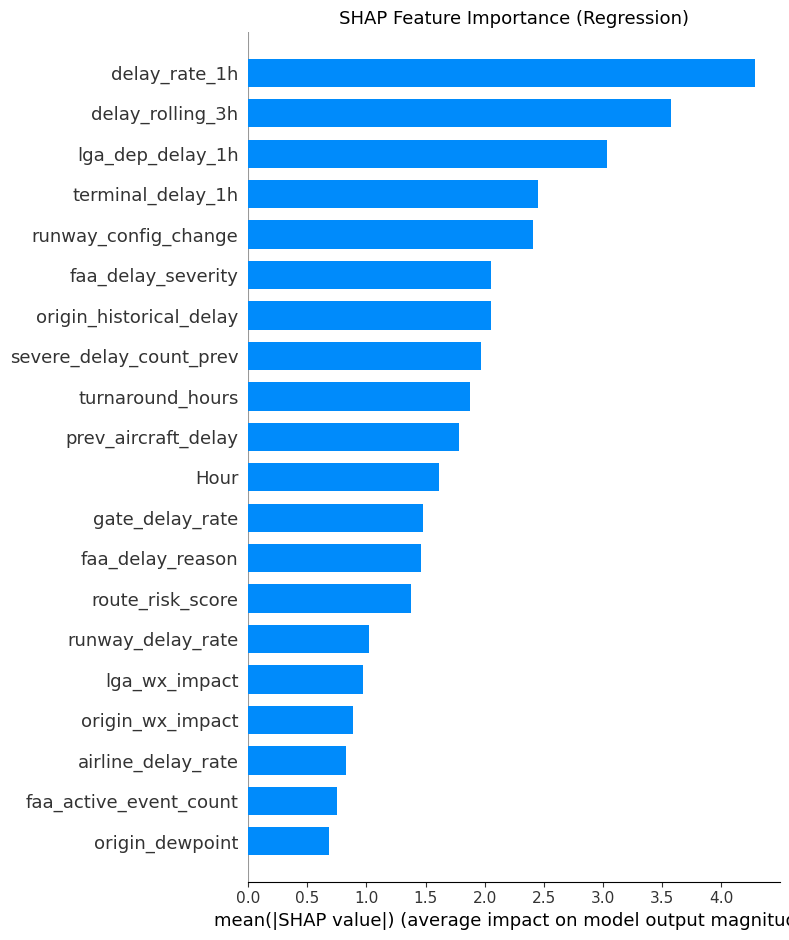

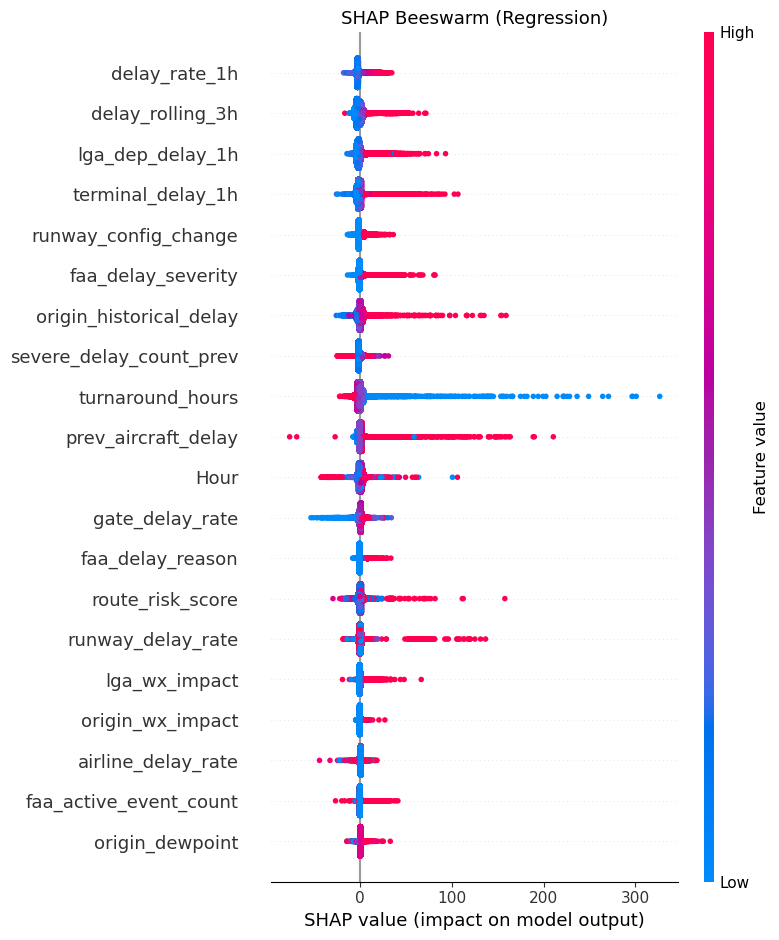

Saved: regression_shap_bar.png, regression_shap_beeswarm.png


In [19]:
# --- SHAP summary plots ---

# Bar plot
fig1, ax1 = plt.subplots(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_reg, plot_type="bar", max_display=20, show=False)
ax1.set_title("SHAP Feature Importance (Regression)", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "regression_shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

# Beeswarm plot
fig2, ax2 = plt.subplots(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_reg, max_display=20, show=False)
ax2.set_title("SHAP Beeswarm (Regression)", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "regression_shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: regression_shap_bar.png, regression_shap_beeswarm.png")

## 10. Lookahead Degradation

In [20]:
# --- 7.1 Lookahead: RMSE Model ---
# V9.0: 6 lag features that become stale with lookahead
# (same lag set as V7.0; feature count changed but lag features unchanged)
lag_features_lookahead = [
    'delay_rate_1h', 'delay_rolling_3h',
    'severe_delay_count_prev', 'terminal_delay_1h',
    'lga_dep_delay_1h', 'runway_config_change',
]
lag_features_lookahead = [f for f in lag_features_lookahead if f in X_test_reg.columns]

test_date_col = test['Date'].dt.date
flights_per_day = test_date_col.value_counts().mean()
flights_per_hour = flights_per_day / 16
print(f'Lag features for lookahead: {len(lag_features_lookahead)}')
print(f'Features: {lag_features_lookahead}')
print(f'Flights/hour: {flights_per_hour:.1f}')

lookahead_reg_results = []
for lookahead_h in [0, 1, 2, 3, 4, 5]:
    shift_n = int(round(flights_per_hour * lookahead_h))
    X_shifted = X_test_reg.copy()

    if shift_n > 0:
        for col in lag_features_lookahead:
            X_shifted[col] = X_shifted.groupby(test_date_col)[col].shift(shift_n)
        X_shifted = X_shifted.fillna(train_medians)

    preds = reg_model.predict(X_shifted)
    rmse_h = np.sqrt(mean_squared_error(y_test_reg, preds))
    mae_h = mean_absolute_error(y_test_reg, preds)
    r2_h = r2_score(y_test_reg, preds)

    lookahead_reg_results.append({
        'lookahead_h': lookahead_h,
        'shift_flights': shift_n,
        'rmse': rmse_h,
        'mae': mae_h,
        'r2': r2_h,
    })

# Display
print('\n' + '=' * 70)
print('LOOKAHEAD WINDOW EVALUATION (RMSE Model)')
print('=' * 70)
print(f'{"Lookahead":>10} {"Shift":>8} {"RMSE":>8} {"MAE":>8} {"R²":>8} {"ΔMAE":>8}')
print('-' * 55)
base_mae = lookahead_reg_results[0]['mae']
for r in lookahead_reg_results:
    delta_mae = r['mae'] - base_mae
    print(f'{r["lookahead_h"]:>8}h {r["shift_flights"]:>8} {r["rmse"]:>8.2f} '
          f'{r["mae"]:>8.2f} {r["r2"]:>8.4f} {delta_mae:>+8.2f}')

Lag features for lookahead: 6
Features: ['delay_rate_1h', 'delay_rolling_3h', 'severe_delay_count_prev', 'terminal_delay_1h', 'lga_dep_delay_1h', 'runway_config_change']
Flights/hour: 31.2

LOOKAHEAD WINDOW EVALUATION (RMSE Model)
 Lookahead    Shift     RMSE      MAE       R²     ΔMAE
-------------------------------------------------------
       0h        0    49.95    22.54   0.2754    +0.00
       1h       31    55.41    26.37   0.1084    +3.83
       2h       62    56.01    26.43   0.0888    +3.89
       3h       94    55.82    26.16   0.0949    +3.62
       4h      125    55.77    26.11   0.0968    +3.57
       5h      156    56.34    26.25   0.0781    +3.71


### 10.1 Quantile Lookahead

In [21]:
# --- 7.2 Lookahead: Quantile Models ---

lookahead_q50_results = []
for lookahead_h in [0, 1, 2, 3, 4, 5]:
    shift_n = int(round(flights_per_hour * lookahead_h))
    X_shifted = X_test_reg.copy()

    if shift_n > 0:
        for col in lag_features_lookahead:
            X_shifted[col] = X_shifted.groupby(test_date_col)[col].shift(shift_n)
        X_shifted = X_shifted.fillna(train_medians)

    p50 = quantile_models['q50'].predict(X_shifted)
    p90 = quantile_models['q90'].predict(X_shifted)
    p10 = quantile_models['q10'].predict(X_shifted)

    mae_50 = mean_absolute_error(y_test_reg, p50)
    mae_90 = mean_absolute_error(y_test_reg, p90)
    coverage = np.mean((y_test_reg.values >= p10) & (y_test_reg.values <= p90))
    width = (p90 - p10).mean()

    lookahead_q50_results.append({
        'lookahead_h': lookahead_h,
        'mae_q50': mae_50,
        'mae_q90': mae_90,
        'coverage_80': coverage,
        'interval_width': width,
    })

print('=' * 80)
print('LOOKAHEAD: QUANTILE MODELS')
print('=' * 80)
print(f'{"Lookahead":>10} {"Q50 MAE":>10} {"Q90 MAE":>10} {"Coverage":>10} {"Width":>10} {"ΔMAE":>8}')
print('-' * 65)
base = lookahead_q50_results[0]['mae_q50']
for r in lookahead_q50_results:
    delta = r['mae_q50'] - base
    print(f'{r["lookahead_h"]:>8}h {r["mae_q50"]:>10.2f} {r["mae_q90"]:>10.2f} '
          f'{r["coverage_80"]:>9.1%} {r["interval_width"]:>10.1f} {delta:>+8.2f}')

LOOKAHEAD: QUANTILE MODELS
 Lookahead    Q50 MAE    Q90 MAE   Coverage      Width     ΔMAE
-----------------------------------------------------------------
       0h      20.12      41.13     80.0%       57.0    +0.00
       1h      23.66      44.26     75.0%       56.8    +3.54
       2h      23.62      44.06     75.0%       56.3    +3.50
       3h      23.57      43.42     74.8%       55.6    +3.45
       4h      23.50      43.07     75.0%       55.1    +3.38
       5h      23.62      42.76     74.5%       54.3    +3.51


### 10.2 Degradation Plot

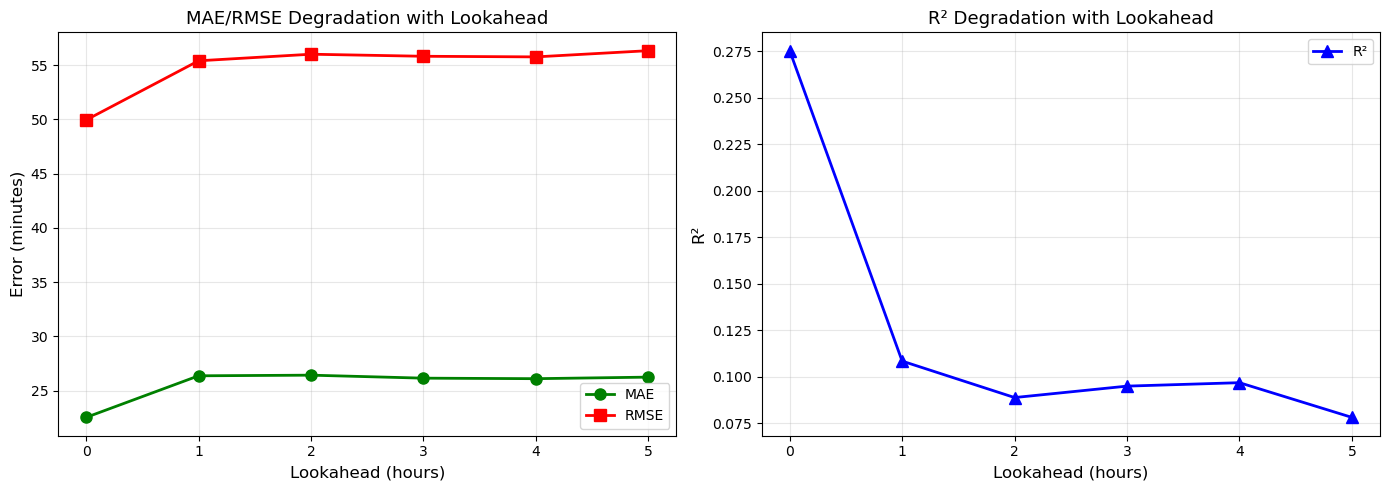

Saved: regression_lookahead_degradation.png


In [22]:
# --- Lookahead degradation plot (regression) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hours = [r['lookahead_h'] for r in lookahead_reg_results]
maes = [r['mae'] for r in lookahead_reg_results]
rmses = [r['rmse'] for r in lookahead_reg_results]
r2s = [r['r2'] for r in lookahead_reg_results]

# MAE/RMSE degradation
axes[0].plot(hours, maes, 'go-', linewidth=2, markersize=8, label='MAE')
axes[0].plot(hours, rmses, 'rs-', linewidth=2, markersize=8, label='RMSE')
axes[0].set_xlabel('Lookahead (hours)', fontsize=12)
axes[0].set_ylabel('Error (minutes)', fontsize=12)
axes[0].set_title('MAE/RMSE Degradation with Lookahead', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(6))

# R² degradation
axes[1].plot(hours, r2s, 'b^-', linewidth=2, markersize=8, label='R²')
axes[1].set_xlabel('Lookahead (hours)', fontsize=12)
axes[1].set_ylabel('R²', fontsize=12)
axes[1].set_title('R² Degradation with Lookahead', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(range(6))

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'regression_lookahead_degradation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: regression_lookahead_degradation.png')

## 11. Dashboard Integration

In [23]:
# --- 8.1 Classification-Guided Display Logic ---
# Design: regression output is shown ONLY when classification indicates delay risk.
#
# | Risk Tier     | Calibrated P | Regression Display                              |
# |---------------|-------------|--------------------------------------------------|
# | CRITICAL ≥0.75| 86.0%       | Q90 as point est + floor 60min                  |
# | HIGH ≥0.30    | 45.5%       | Q50 + [Q10, Q90] interval                       |
# | MEDIUM ≥0.15  | 21.4%       | "Possible delay ≤{Q90}" only if Q50>5           |
# | LOW <0.15     | 7.5%        | "On time" — do NOT show regression               |
#
# Design principles:
#   - Round all minutes to nearest 5 (operational cleanliness)
#   - Never display negative delays (early arrivals)
#   - CRITICAL uses Q90 (not Q50) because Q50 severely underestimates extreme delays
#   - Show interval only for HIGH/CRITICAL (MEDIUM/LOW don't need it)
#
# Regression-to-mean is addressed at the DISPLAY layer, not the model layer:
#   - For CRITICAL flights, floor at 60 min and use Q90
#   - For >120 min actual delays, the operational response is the same as >60 min
#     (cancel connections, reroute aircraft, notify ground handling)

print("Dashboard Integration:")
print("  Classification model → risk_tier + delay_probability")
print("  Regression Q50       → predicted_delay_minutes (median estimate)")
print("  Regression [Q10,Q90] → confidence interval")
print("  Regression [Q05,Q95] → conservative bounds")
print("  SHAP                 → top 3 delay reasons per flight")
print()
print("Display logic: conditional on risk tier")
print("  CRITICAL (≥0.75): show Q90 with floor 60 min")
print("  HIGH     (≥0.30): show Q50 + [Q10, Q90] interval")
print("  MEDIUM   (≥0.15): show 'possible delay' only if Q50 > 5")
print("  LOW      (<0.15): show 'on time' — suppress regression")


Dashboard Integration:
  Classification model → risk_tier + delay_probability
  Regression Q50       → predicted_delay_minutes (median estimate)
  Regression [Q10,Q90] → confidence interval
  Regression [Q05,Q95] → conservative bounds
  SHAP                 → top 3 delay reasons per flight

Display logic: conditional on risk tier
  CRITICAL (≥0.75): show Q90 with floor 60 min
  HIGH     (≥0.30): show Q50 + [Q10, Q90] interval
  MEDIUM   (≥0.15): show 'possible delay' only if Q50 > 5
  LOW      (<0.15): show 'on time' — suppress regression


## 12. Save Models

In [24]:
# --- 9. Save all models ---

VERSION = 'v9_0'

# RMSE regression model
reg_model_path = MODELS_DIR / f'regression_model_{VERSION}.joblib'
joblib.dump({
    'model': reg_model,
    'model_type': 'CatBoostRegressor',
    'loss_function': 'RMSE',
    'best_params': best_reg_params,
    'rmse': rmse,
    'mae': mae,
    'r2': r2,
    'feature_columns': feature_columns,
    'train_medians': train_medians.to_dict(),
    'version': VERSION,
}, reg_model_path)
print(f'Saved: {reg_model_path}')

# Quantile regression models (Q05, Q10, Q50, Q90, Q95)
for qname, qmodel in quantile_models.items():
    qpath = MODELS_DIR / f'regression_{qname}_{VERSION}.joblib'
    q_preds = quantile_preds[qname]
    joblib.dump({
        'model': qmodel,
        'model_type': 'CatBoostRegressor',
        'loss_function': f'Quantile:alpha={quantile_configs[qname]}',
        'quantile': quantile_configs[qname],
        'mae': float(mean_absolute_error(y_test_reg, q_preds)),
        'feature_columns': feature_columns,
        'train_medians': train_medians.to_dict(),
        'version': VERSION,
    }, qpath)
    print(f'Saved: {qpath}')

# Post-hoc regression calibrators (Q50, Q90)
cal_q50_path = MODELS_DIR / f'regression_calibrator_q50_{VERSION}.joblib'
joblib.dump(cal_q50, cal_q50_path)
print(f'Saved: {cal_q50_path}')

cal_q90_path = MODELS_DIR / f'regression_calibrator_q90_{VERSION}.joblib'
joblib.dump(cal_q90, cal_q90_path)
print(f'Saved: {cal_q90_path}')

# Save config
reg_config = {
    'model_type': 'CatBoostRegressor',
    'version': VERSION,
    'target': 'Total_Calculated_Delay',
    'rmse_model': {
        'rmse': float(rmse),
        'mae': float(mae),
        'r2': float(r2),
    },
    'quantile_models': {
        qname: {
            'alpha': quantile_configs[qname],
            'mae': float(mean_absolute_error(y_test_reg, quantile_preds[qname])),
        }
        for qname in quantile_configs
    },
    'prediction_interval': {
        'coverage_80': float(coverage_80),
        'coverage_90': float(coverage_90),
        'mean_width_80': float(interval_width_80.mean()),
        'mean_width_90': float(interval_width_90.mean()),
    },
    'sample_weighting': {
        'used': use_weighted,
    },
    'features': feature_columns,
    'n_features': len(feature_columns),
    'lookahead_degradation': [
        {'hours': r['lookahead_h'], 'mae': float(r['mae']), 'rmse': float(r['rmse'])}
        for r in lookahead_reg_results
    ],
    'data': {
        'train_size': int(len(X_train_reg)),
        'test_size': int(len(X_test_reg)),
        'train_delay_mean': float(y_train_reg.mean()),
        'test_delay_mean': float(y_test_reg.mean()),
    },
}

reg_config_path = PROJECT_ROOT / 'outputs' / f'regression_config_{VERSION}.json'
with open(reg_config_path, 'w') as f:
    json.dump(reg_config, f, indent=2)
print(f'Saved: {reg_config_path}')

print(f'\nTotal files saved: {1 + len(quantile_models) + 2 + 1} '
      f'(1 RMSE + {len(quantile_models)} quantile + 2 calibrators + 1 config)')

Saved: ../../../models/regression_model_v9_0.joblib
Saved: ../../../models/regression_q05_v9_0.joblib
Saved: ../../../models/regression_q10_v9_0.joblib
Saved: ../../../models/regression_q50_v9_0.joblib
Saved: ../../../models/regression_q90_v9_0.joblib
Saved: ../../../models/regression_q95_v9_0.joblib
Saved: ../../../models/regression_calibrator_q50_v9_0.joblib
Saved: ../../../models/regression_calibrator_q90_v9_0.joblib
Saved: ../../../outputs/regression_config_v9_0.json

Total files saved: 9 (1 RMSE + 5 quantile + 2 calibrators + 1 config)


### 12.1 Final Summary

In [25]:
# --- Final summary ---
print('\n' + '=' * 80)
print('NOTEBOOK 08 SUMMARY: Regression Model (V9.0: 21 features)')
print('=' * 80)

print(f'\n--- RMSE Model Performance ---')
print(f'RMSE: {rmse:.2f} min')
print(f'MAE:  {mae:.2f} min')
print(f'R²:   {r2:.4f}')

print(f'\n--- Quantile Models ---')
for qn in ['q05', 'q10', 'q50', 'q90', 'q95']:
    qm = mean_absolute_error(y_test_reg, quantile_preds[qn])
    print(f'  {qn.upper()} MAE: {qm:.2f} min')
print(f'  80% Interval [Q10,Q90] Coverage: {coverage_80:.1%}')
print(f'  90% Interval [Q05,Q95] Coverage: {coverage_90:.1%}')
print(f'  80% Mean Width: {interval_width_80.mean():.1f} min')
print(f'  90% Mean Width: {interval_width_90.mean():.1f} min')

print(f'\n--- Sample Weighting ---')
print(f'  Tail bias improved: {tail_improved}')
print(f'  MAE degradation: {mae_degradation:+.2f} min (threshold: 2.0)')
print(f'  Used in production: {use_weighted}')

print(f'\n--- Post-hoc Calibration ---')
print(f'  Q50 MAE: uncal={mean_absolute_error(y_test_reg, pred_q50):.2f}, cal={mean_absolute_error(y_test_reg, pred_q50_cal):.2f}')
print(f'  Q90 MAE: uncal={mean_absolute_error(y_test_reg, pred_q90):.2f}, cal={mean_absolute_error(y_test_reg, pred_q90_cal):.2f}')
print(f'  Verdict: Calibrators NOT deployed (Q50 worse, Q90 breaks upper-bound semantics)')

print(f'\n--- Lookahead Degradation (RMSE model) ---')
for r in lookahead_reg_results:
    print(f'  {r["lookahead_h"]}h: MAE={r["mae"]:.2f}, RMSE={r["rmse"]:.2f}, R²={r["r2"]:.4f}')

print(f'\n--- SHAP Top 5 (RMSE) ---')
for i, (_, row) in enumerate(shap_importance.head(5).iterrows()):
    print(f'  #{i+1}: {row["feature"]} ({row["mean_abs_shap"]:.4f})')

print(f'\n--- Production Deployment ---')
print(f'  Point estimate: Q50 uncalibrated (best MAE)')
print(f'  80% interval:  [Q10, Q90] uncalibrated')
print(f'  90% interval:  [Q05, Q95] uncalibrated')
print(f'  SHAP:          top 3 delay reasons per flight (from Q50 model)')

print(f'\n--- Saved Files ({VERSION}) ---')
print(f'  {reg_model_path}')
for qn in quantile_models:
    print(f'  {MODELS_DIR / f"regression_{qn}_{VERSION}.joblib"}')
print(f'  {cal_q50_path} (reference only)')
print(f'  {cal_q90_path} (reference only)')
print(f'  {reg_config_path}')


NOTEBOOK 08 SUMMARY: Regression Model (V9.0: 21 features)

--- RMSE Model Performance ---
RMSE: 49.95 min
MAE:  22.54 min
R²:   0.2754

--- Quantile Models ---
  Q05 MAE: 31.62 min
  Q10 MAE: 27.99 min
  Q50 MAE: 20.12 min
  Q90 MAE: 41.13 min
  Q95 MAE: 65.44 min
  80% Interval [Q10,Q90] Coverage: 80.0%
  90% Interval [Q05,Q95] Coverage: 90.2%
  80% Mean Width: 57.0 min
  90% Mean Width: 89.3 min

--- Sample Weighting ---
  Tail bias improved: True
  MAE degradation: +10.88 min (threshold: 2.0)
  Used in production: False

--- Post-hoc Calibration ---
  Q50 MAE: uncal=20.12, cal=22.20
  Q90 MAE: uncal=41.13, cal=22.68
  Verdict: Calibrators NOT deployed (Q50 worse, Q90 breaks upper-bound semantics)

--- Lookahead Degradation (RMSE model) ---
  0h: MAE=22.54, RMSE=49.95, R²=0.2754
  1h: MAE=26.37, RMSE=55.41, R²=0.1084
  2h: MAE=26.43, RMSE=56.01, R²=0.0888
  3h: MAE=26.16, RMSE=55.82, R²=0.0949
  4h: MAE=26.11, RMSE=55.77, R²=0.0968
  5h: MAE=26.25, RMSE=56.34, R²=0.0781

--- SHAP To

### 12.2 Save Regression Context

In [26]:
# === Save regression context for NB06 ===
import pickle
reg_context = {
    'rmse_model': rmse_model if 'rmse_model' in dir() else None,
    'quantile_models': quantile_models if 'quantile_models' in dir() else {},
    'best_rmse_params': best_rmse_params if 'best_rmse_params' in dir() else {},
}
pickle.dump(reg_context, open(DATA_PROCESSED / 'arrival_regression_context.pkl', 'wb'))
print('Saved regression context for NB06')


Saved regression context for NB06
